# 04 — Sequential calibration ablation
Test the sequential extension separately from projected marginal calibration. Every specification uses identical initialization, data order, forecast random numbers, and a fixed epoch budget. This removes checkpoint-selection and unequal-training-duration confounds.

In [1]:
import sys
from pathlib import Path
import matplotlib.pyplot as plt
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT / 'src'))
from innovcal.ca_rnn import TrainingConfig
from innovcal.data import simulate_multivariate_series
from innovcal.experiments import run_sequential_ablation
OUT = ROOT / 'results' / 'sequential_ablation'; OUT.mkdir(parents=True, exist_ok=True)

In [2]:
values = simulate_multivariate_series(1400, regime='heteroskedastic', seed=404)
config = TrainingConfig(epochs=100, batch_size=64, seed=404)
ablation_result = run_sequential_ablation(
    values,
    sequential_weights=[500.0, 2000.0, 5000.0, 10000.0],
    calibration_weight=100.0,
    training_config=config,
)
ablation = ablation_result.metrics
display(ablation)
ablation.to_csv(OUT / 'ablation.csv', index=False)
for name, history in ablation_result.histories.items():
    safe_name = name.lower().replace(' ', '_').replace('(', '').replace(')', '')
    history.to_csv(OUT / f'{safe_name}_history.csv', index=False)

,model,lambda_cal,lambda_seq,epochs,nll,rmse,energy_score,coverage,interval_width,interval_score,pit_calibration_error,pit_mean_absolute_autocorrelation,pit_mean_ks,coordinate_pit_calibration_error,coordinate_pit_mean_absolute_autocorrelation,coordinate_pit_mean_ks
0,RNN,0.0,0.0,100,5.523413,0.918320,1.210001,0.883654,2.949924,4.055414,0.000906,0.053524,0.057856,0.001305,0.058541,0.068642
1,CA-RNN,100.0,0.0,100,5.189032,0.916304,1.201123,0.908654,3.133253,3.896588,0.000838,0.052068,0.055421,0.001256,0.056861,0.061686
2,CA-RNN sequential (500),100.0,500.0,100,5.182958,0.917207,1.202341,0.913462,3.169320,3.904721,0.000938,0.052293,0.056722,0.001367,0.055487,0.062224
3,CA-RNN sequential (2000),100.0,2000.0,100,5.166813,0.919384,1.205141,0.917308,3.258366,3.910949,0.001117,0.049398,0.060601,0.001586,0.050947,0.065761
4,CA-RNN sequential (5000),100.0,5000.0,100,5.194819,0.922750,1.212284,0.930769,3.412720,3.962393,0.001437,0.045534,0.067566,0.001874,0.044812,0.070436
5,CA-RNN sequential (10000),100.0,10000.0,100,5.257835,0.927006,1.224816,0.944231,3.637024,4.071807,0.002062,0.043041,0.081165,0.002397,0.041159,0.079988


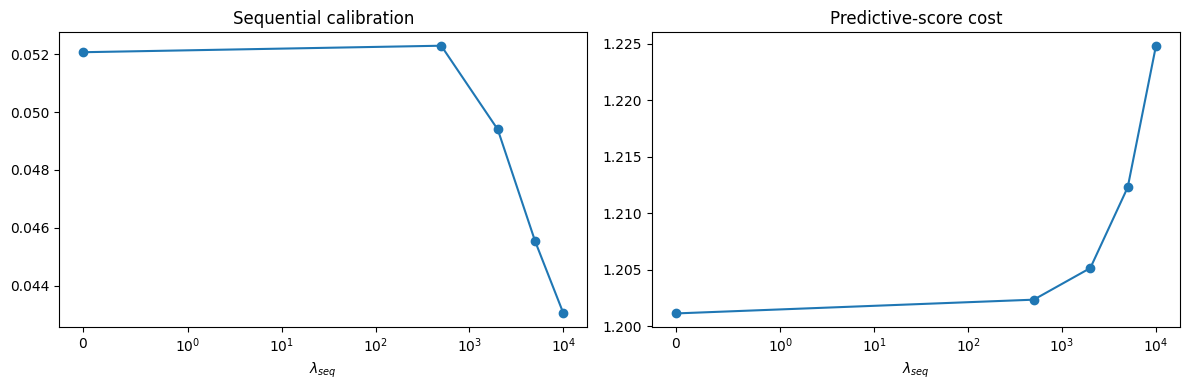

In [3]:
sequential = ablation.query("lambda_cal > 0").sort_values('lambda_seq')
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(sequential.lambda_seq, sequential.pit_mean_absolute_autocorrelation, marker='o')
axes[0].set_xscale('symlog', linthresh=1)
axes[0].set_title('Sequential calibration')
axes[0].set_xlabel(r'$\lambda_{seq}$')
axes[1].plot(sequential.lambda_seq, sequential.energy_score, marker='o')
axes[1].set_xscale('symlog', linthresh=1)
axes[1].set_title('Predictive-score cost')
axes[1].set_xlabel(r'$\lambda_{seq}$')
plt.tight_layout()

## Reading the ablation
Do not select a final weight from this test table. Look for a reproducible region in which PIT autocorrelation decreases without a disproportionate deterioration in NLL, Energy Score, interval score, or width. The later confirmatory design must select the weight using validation data and fresh seeds.